# Bayesian Statistical Inference: I

*Davide Gerosa (Milano-Bicocca)* 

##### Reading:

- [Textbook](http://press.princeton.edu/titles/10159.html) Chapter 5.
- [Jake VanderPlas's blog "Frequentism and Bayesianism: A Practical Introduction"](http://jakevdp.github.io/blog/2014/03/11/frequentism-and-bayesianism-a-practical-intro/)
- [Jake VanderPlas: "Frequentism and Bayesianism: A Python-driven Primer"](https://arxiv.org/abs/1411.5018)
- [Hogg, Bovy and Lang: "Data analysis recipes: Fitting a model to data"](https://arxiv.org/abs/1008.4686)


##### For those who want to dive deep:

- [Jake VanderPlas's workshop "Bayesian Astronomy"](https://github.com/jakevdp/BayesianAstronomy)
- [D. Sivia and J. Skilling: "Data Analysis: A Bayesian Tutorial"](https://www.amazon.com/Data-Analysis-Bayesian-Devinderjit-Sivia/dp/0198568320)
- [E.T. Jaynes: "Probability Theory: The Logic of Science"](http://bayes.wustl.edu/etj/prob/book.pdf)
- [E.T. Jaynes: "Confidence Intervals vs. Bayesian intervals"](http://bayes.wustl.edu/etj/articles/confidence.pdf)
- [This great explanation of confidence levels versus credible regions on Stackexchange](https://stats.stackexchange.com/questions/2272/whats-the-difference-between-a-confidence-interval-and-a-credible-interval/2287#2287)



This course is based on previous work by many people. See [here]((https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/README.md) for credits.




In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
np.random.seed(42)

## From "Bayes Rule" To "Bayesian Inference" <a class="anchor" id="one"></a>

**Recap from a few weeks ago**. We had that 

$$p(x,y) = p(x|y)p(y) = p(y|x)p(x)$$

The marginal probability is

$$p(x) = \int p(x,y)dy,$$

and therefore

$$p(y|x) = \frac{p(x|y)p(y)}{p(x)} = \frac{p(x|y)p(y)}{\int p(x|y)p(y) dy}$$

This is **Bayes' rule**. Now we make the step to **Bayesian statistics**.

### Recap: MLE applied to a heteroscedastic Gaussian

Assume $N$ measurements, $\{x_i\}$, where the uncertainty for each measurement is Gaussian with
a known $\sigma_i$. The likelihood of one measurement is 

$$L \equiv p(x_i|\mu,\sigma_i) = \frac{1}{\sigma_i\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma_i^2}\right).$$


and therefore the likelihood of all N measurements is

$$L \equiv p(\{x_i\}|\mu,\sigma_i) = \prod_{i=1}^N \frac{1}{\sigma_i\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma_i^2}\right).$$

Let's draw a homoscedastic sample of $\{x_i\}$ from a Gaussian and see what happens with $L$. First generate a sample of $N$ points drawn from $\mathcal{N}(\mu,\sigma)$.

In [2]:
sampleSize = 3
mu = 0.1
sigma = 0.2 
sample = norm(mu, sigma).rvs(sampleSize) 
print(sample)

[0.19934283 0.07234714 0.22953771]


As we did in the MLE lectures, let's now compute probabilities for each point centered at the measured value across a grid, and multiply the probabilities together to find the likelihood for the dataset.

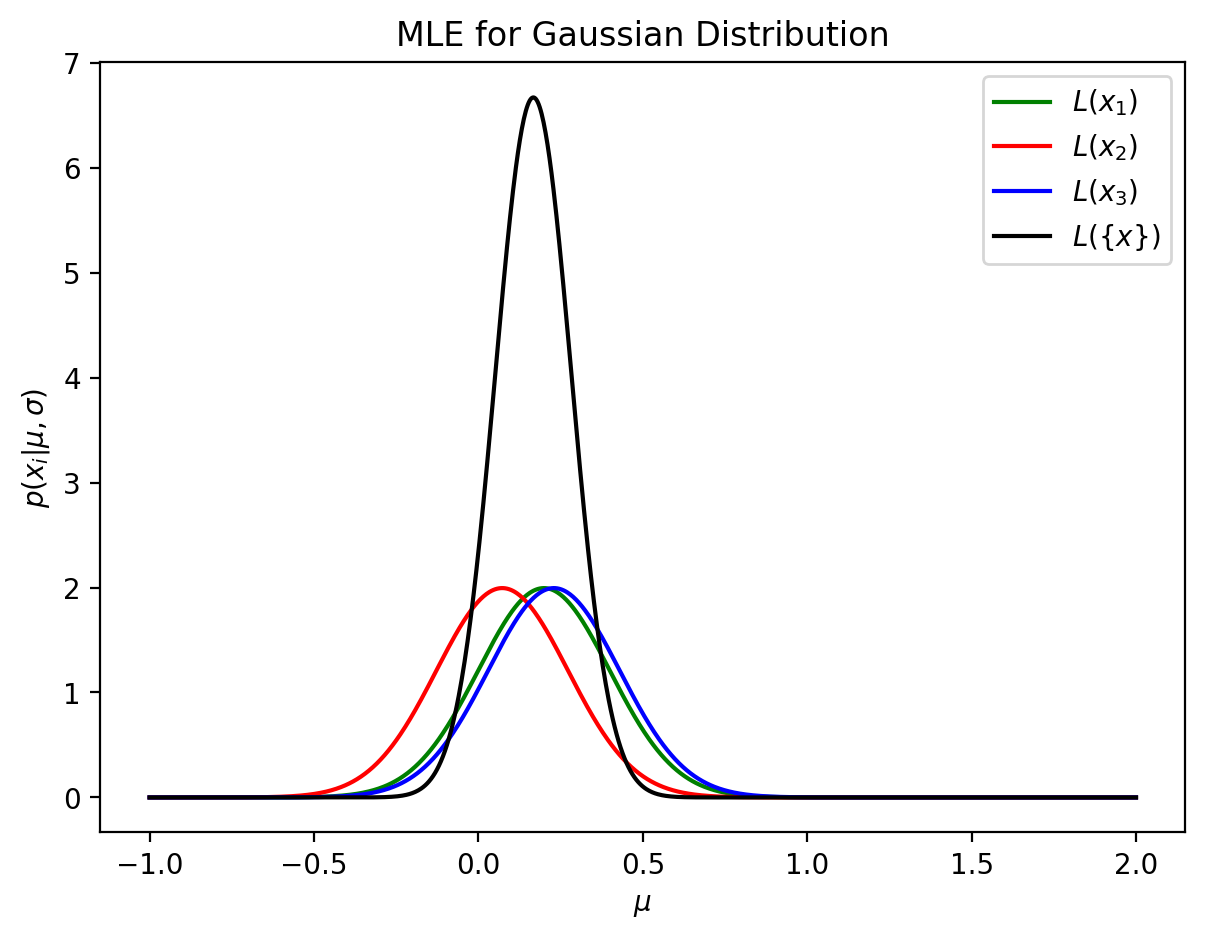

In [3]:
muGrid = np.linspace(-1,2,1000)

L1 = norm(sample[0], sigma).pdf(muGrid) 
L2 = norm(sample[1], sigma).pdf(muGrid) 
L3 = norm(sample[2], sigma).pdf(muGrid) 
L = L1 * L2 * L3

# plot
fig, ax = plt.subplots(figsize=(7, 5))
plt.plot(muGrid, L1, ls='-', c='green', 
         label=r'$L(x_1)$')
plt.plot(muGrid, L2, ls='-', c='red', 
         label=r'$L(x_2)$')
plt.plot(muGrid, L3, ls='-', c='blue', 
         label=r'$L(x_3)$')
plt.plot(muGrid, L, ls='-', c='black', 
         label=r'$L(\{x\})$')

plt.xlabel('$\mu$')
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.title('MLE for Gaussian Distribution')
plt.legend()
plt.show() 

But what if $\mu$ is the mass of a galaxy. Surely that cannot be negative.  That's prior information!

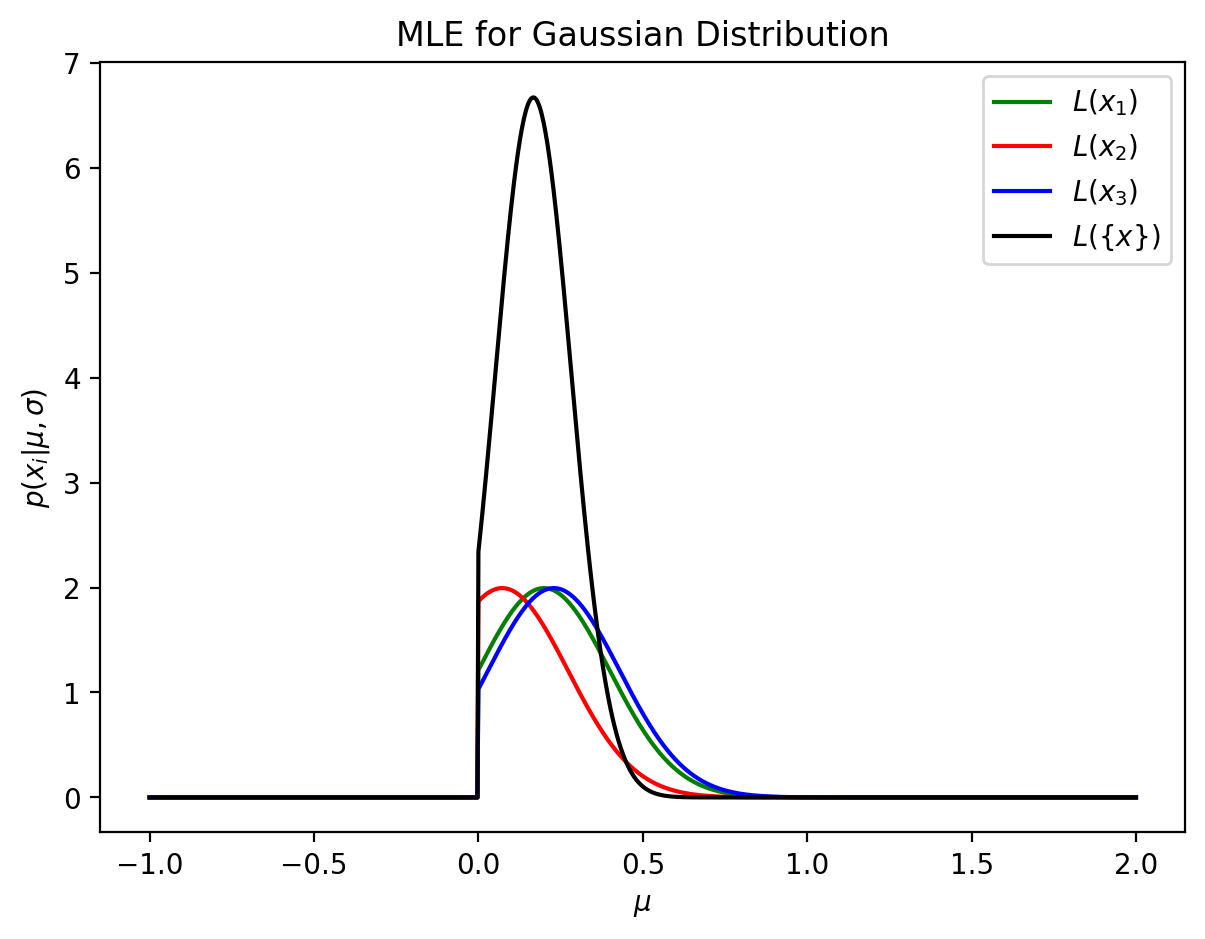

In [4]:
muMin = 0
L1[muGrid < muMin] = 0
L2[muGrid < muMin] = 0
L3[muGrid < muMin] = 0
L = L1 * L2 * L3

# plot
fig, ax = plt.subplots(figsize=(7, 5))
plt.plot(muGrid, L1, ls='-', c='green', label=r'$L(x_1)$')
plt.plot(muGrid, L2, ls='-', c='red', label=r'$L(x_2)$')
plt.plot(muGrid, L3, ls='-', c='blue', label=r'$L(x_3)$')
plt.plot(muGrid, L, ls='-', c='black', label=r'$L(\{x\})$')

#plt.xlim(0.2, 1.8)
#plt.ylim(0, 8.0)
plt.xlabel('$\mu$')
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.title('MLE for Gaussian Distribution')
plt.legend()
plt.show() 

Clearly the *maximum is unchanged in this trivial example*, but the distribution is truncated leading to very different uncertainty estimates than what one would naively get by assuming that all $\mu$ values are equally likely.

Let's put this idea on solid ground now...

### The essence of the Bayesian approach 

- The basic premise of the Bayesian method is that probability statements are not limited to data,  but can be made for model parameters and models themselves. 
- Inferences are made by producing  probability density functions (pdfs); most notably, **model parameters are treated as random variables**.
- These **pdfs represent our "belief spread" in what the model parameters are**. They have nothing to do with outcomes of repeated experiments (although the shape of resulting distributions can often coincide).


In short:

- In frequentist analysis: **the parameters are fixed** and the data change (at least ideally with imaginary repeated measurements). 
- In Bayesian analysis: **the data are fixed** and the parameters change (as random variables). 


### Brief history 

- The **Reverend Thomas Bayes (1702–1761)** was an English amateur mathematician who wrote a manuscript 
on how to combine an initial belief with new data to arrive at an improved belief. 
- The manuscript 
was published posthumously in 1763 and gave rise to the name Bayesian statistics. 
- **Laplace** rediscovered the Bayesian approach a decade after it was originally published, and greatly clarified some principles.  
- Howevever, Bayesian statistics did not find its ways into mainstream science until well into the 20th century, and widespread usage has been hindered until the 1990s with the advent of cheap computing that can map out the Bayesian probability distributions.

![](https://upload.wikimedia.org/wikipedia/commons/d/d4/Thomas_Bayes.gif?1613667187659)

### Bayesian Statistical Inference

Up to now we have been computing the **likelihood** $p(D\,|\,\theta)$.  In Bayesian inference, we instead evaluate the **posterior probability** taking into account **prior** information.

Recall that Bayes' Rule is:

$$p(\theta\,|\,D) = \frac{p(D|\theta)\,p(\theta)}{p(D)},$$

where $D$ is for data and $M$ is for model. Or in words,

$${\rm Posterior \,\, Probability} = \frac{{\rm Likelihood}\times{\rm Prior}}{{\rm Evidence}}.$$

If we explicitly recognize additional assumptions, $I$, and the model itseld, $M$, then we can write:

$$p(M,\theta \,|\,D,I) = \frac{p(D\,|\,M,\theta,I)\,p(M,\theta\,|\,I)}{p(D\,|\,I)},$$

This is the most general form, but often some of these items will be omitted depending on the context.  If needed, the prior can be expanded to 

$$p(M,\theta\,|\,I) = p(\theta\,|\,M,I)\,p(M\,|\,I),$$


**NOTE** 

We don't often care about **the evidence $p(D\,|\,I)$** because it does not depend on model parameters. We usually set it to $1$ for parameter estimation. **BUT** it's at the heart of Bayesian model selection (which we'll look at later) since it gives us a way of ranking different model descriptions of the data.  

**The Bayesian Statistical Inference process** is then
1. formulate the likelihood, $p(D\,|\,M,\theta,I)$
2. chose a prior, $p(M,\theta\,|\,I)$, which incorporates *other information beyond the data in $D$*
3. determine the posterior pdf, $p(M,\theta \,|\,D,I)$
4. explore/map the posterior distribution $p(M,\theta \,|\,D,I)$ 
5. extract some summary statistics and quantify the uncertainty of the model parameter estimates
6. perform model selection to find the most apt description of the data

Compare this bullet points with the MLE workflow from a few lectures ago: what's similar? And what's different?

Before applying this expression, we need to discuss how to choose priors.

## Bayesian priors: what are they & how do I choose them? 

Priors can be **informative** or **uninformative**.  As it sounds, informative priors are based on existing information (including previously obtained data, but not the data considered right now) that might be available.  Uniformative priors can be thought of as "default" priors, i.e., what your prior is when you never used
any data, e.g, a "flat" prior like $p(\theta|M,I) \propto {\rm C}$.

Detailed discussion can be found in Section 5.2 in the textbook. In general, we want our inferences to be ***data dominated*** rather than prior dominated, so we try to use ***weakly-informative priors***. There are three
main principles used to choose a prior: 


### (i) The principle of indifference

Essentially this means adopting a uniform prior, though you have to be a bit careful.  Saying that an asteroid is equally likely to hit anywhere on the Earth is not the same as saying that all latitudes of impact are equally likely.  

Assuming $1/6$ for a six-side die, or $1/2$ for heads and tails of a fair coin, would be an example of indifference.

### (ii) The principle of invariance (or consistency)

This applies to location and scale invariance.  

**Location invariance** suggests a uniform prior, within the accepted bounds: $p(\theta|I) \propto 1/(\theta_{max}-\theta_{min})$ for $\theta_{min} \le \theta \le \theta_{max}$. 

**Scale invariance** gives us priors that look like $p(\theta|I) \propto 1/\theta$, which implies a uniform
prior for ln($\theta$), i.e. a prior that gives equal weight over many orders of magnitude. 

### (iii) The principle of maximum entropy

We will not discuss it here - for more details, see Section 5.2.2 in the textbook.
 
It is often true that Bayesian analysis and traditional MLE are essentially equivalent. However, in some cases, considering the priors can have significant consequences, as we will see later. 

We will skip examples of very steep priors and their consequences; in the astronomy literature these are called **Eddington-Malmquist** and **Lutz-Kelker** biases (see Chapter 5 in the textbook if you are interested as well as [here](https://en.wikipedia.org/wiki/Lutz%E2%80%93Kelker_bias)). 



### Conjugate Priors

In special combinations of priors and likelihood functions, the resulting posterior probability distribution is from the same function family as the prior. These priors are called **conjugate priors** and give a convenient way for generalizing computations. There are exhaustive tables [here](https://www.wikiwand.com/en/Conjugate_prior#/Table_of_conjugate_distributions). 

**EXAMPLE**

If the likelihood is Gaussian and the prior function is Gaussian, then so too is the posterior distribution! So the conjugate prior for a Gaussian likelihood is a Gaussian.

For data drawn from a Gaussian likelihood equal to $\mathcal{N}(\bar{x},s)$ (where $\bar{x}$ is the sample mean and $s$ is the sample standard deviation), with a prior on the underlying parameters $\mathcal{N}(\mu_p,\sigma_p)$, the posterior is $\mathcal{N}(\mu^0,\sigma^0)$, where

$$\mu^0 = \frac{\mu_p/\sigma_p^2 + \bar{x}/s^2}{1/\sigma_p^2 + 1/s^2},\quad \sigma^0 = \left( 1/\sigma_p^2 + 1/s^2 \right)^{-1/2} $$


### Hierarchical Bayes

A generalization to this choice of prior is called ***hierarchical Bayesian modeling***. I have an active researcn program in this area. ([Taylor and Gerosa 2018](https://arxiv.org/abs/1806.08365), [Moore and Gerosa 2021](https://arxiv.org/abs/2108.02462), [Vitale Gerosa et al 2022](https://arxiv.org/abs/2007.05579), [Tenorio Gerosa 2026](https://arxiv.org/abs/2601.02467))

In this class, we will look at employing prior distributions that have fixed shapes. In hierarchical Bayesian modeling, the parameters of the prior distribution (called ***hyperparameters***) become part of the search. The data informs not only properties of individual events but also the shape of the prior. Those prior parameters then get their own priors, called ***hyperpriors***. 

**The whole analysis is then hierarchical, corresponding to multiple layers of inference.** 

This was first introduced in astrophysics by the exoplanets people. They have lots of [exoplanet discoveries](https://exoplanets.nasa.gov/discovery/discoveries-dashboard/):
- Each of those discoveries started with some lightcurve data, where they fit a likelihood model to that data to deduce parameters of the system (mass of the planet, period, eccentricity, inclination, etc)
- If each event is taken by itself, the prior on its parameter is uninformative. 
- ***BUT*** that prior should really be describing the underlying distribution of orbital periods, eccentricies, etc. So we can use our data not only to inform the properties of each system, but to map out the demographic distribution of exoplanet periods and more! This paper is really cool: [arxiv:1406.3020](https://arxiv.org/abs/1406.3020).

The same happens in my research field, gravitational-wave astronomy (see e.g. [arxiv:2111.03634](https://arxiv.org/abs/2111.03634)). 
- We detect merging black holes and we first use the data to infer the properties of individual objects (these are parameters like the masses of the black holes, their spins, the redshift, etc). 
- In order to do this, one needs to set a prior.
- But now that we have detected many black holes, we also want to inform how the entire population of systems looks like. 
- The event prior is now informative, but depends on our model for stellar evolution (how stars evolved in to black holes, details of the supernova expansion, the galactic host, etc etc). 

A highly non-trivial complication is that the the individual events are *not* representative of the population we're trying to infer, but they are selection biased (e.g. [Gerosa Bellotti 2024](https://arxiv.org/abs/2404.16930))

[This is an awesome example](http://varianceexplained.org/r/empirical_bayes_baseball/) using baseball statistics (really fun to read!), explaining a practical approximation to hierarchical Bayesian statistics called "Empirical Bayes"


For details about hierarchical Bayesian modeling, we wrote a long review article with all the mathemathical derivation of the method and application to gravitational-wave physics (but careful, heavy stats in there!)

*Inferring the properties of a population of compact binaries in presence of selection effects*.
S. Vitale, D. Gerosa, W. Farr, S. Taylor [arxiv:2007.05579](https://arxiv.org/abs/2007.05579)

Anyway, let's move on...

## Bayesian credible regions <a class="anchor" id="three"></a>

In the **frequentist paradigm**, the meaning of the *confidence interval* $\mu_0 \pm \sigma_{\mu}$ is 
the interval that would contain the true $\mu$ (from which the data were drawn) in $68\%$ (or X\%) cases
of a large number of *imaginary repeated experiments* (each with a different N values of $\{x_i\}$). 

However, the meaning of the so-called ***Bayesian credible region*** is *fundamentally different*: it is the interval that **I believe** contains the true $\mu$  with a probability of $68%$ (or $X\%$) after I've collected my data (my dear, one and only dataset; no imaginary repetitions). This credible region is the 
relevant quantity in the context of scientific measurements. 

There are several important features of a Bayesian posterior distribution:
- They represent how well we believe a parameter is constrained within a certain range
- We often quote the posterior maximum (**Maximum A Posteriori (MAP)**).
- We also often quote the posterior expectation value (i.e. mean) $\bar{\theta} = \int \theta\, p(\theta|D)d\theta$, or most often median (recall: robust estimator).
- ***The credible regions are not unique***. We can compute them in two different ways (visualized below)
    1. We can integrate downwards from the MAP to enclose $X\%$ ("highest probability density interval"), or
    2. We can integrate inwards from each tail by $X/2\%$ ("equal-tailed interval")


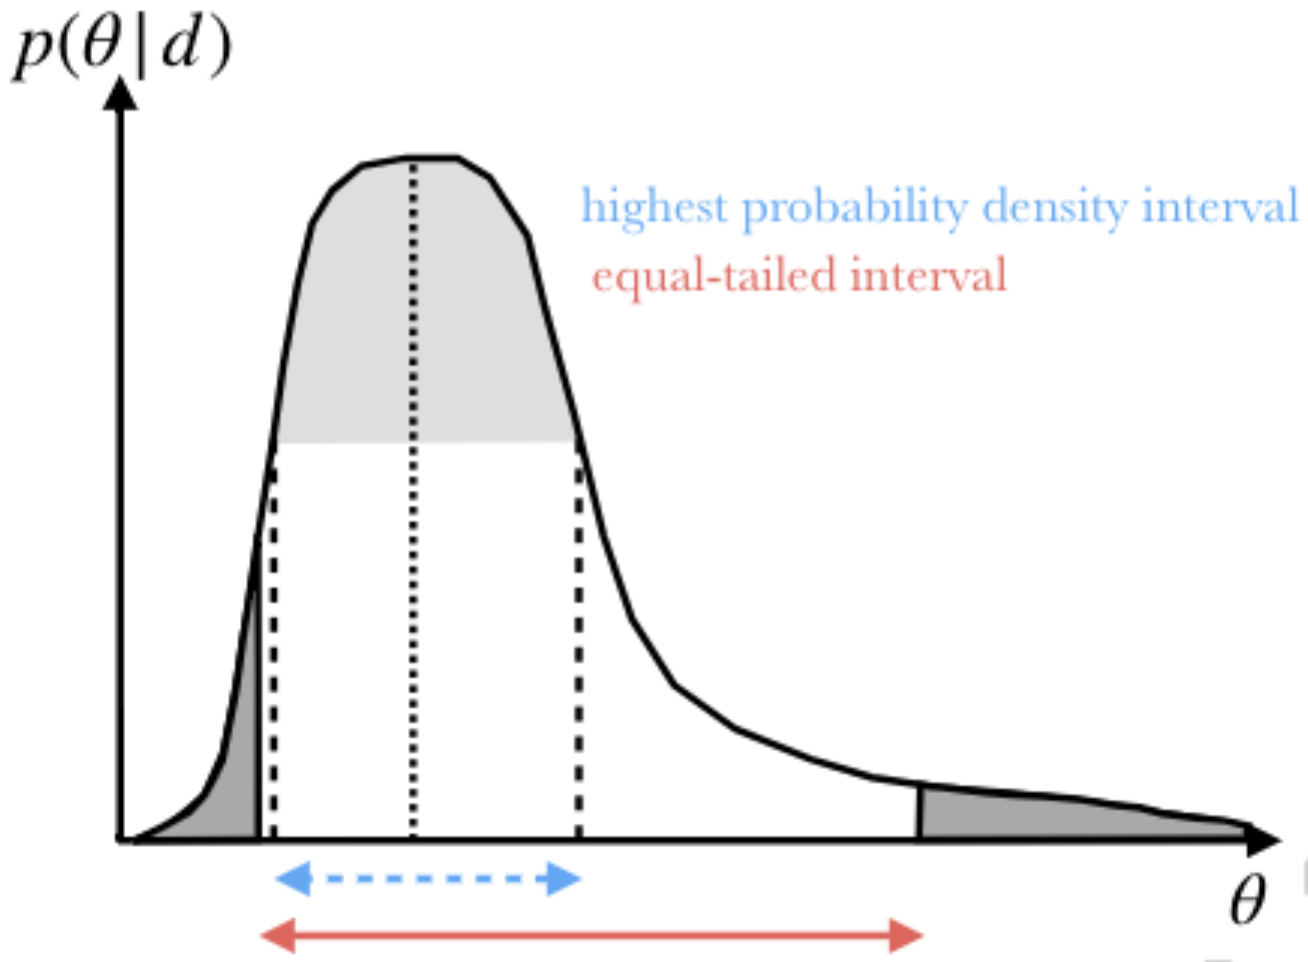

## Simple parameter estimation examples <a class="anchor" id="four"></a>

### A simple coin flip 

Imagine you met a gambler who wanted you to **bet on whether the coin would come up heads or tails**. You watch the gambler work as a number of other people guess (as the coin is flipped). 


Remember the probability of getting $h$ heads in $n$ coin flips is given by the binomial probability distribution
>$P(h|\theta) \propto \theta^h (1-\theta)^{(n-h)}$

with $\theta$ the probability of a head.

We want to calculate and plot the Bayesian posterior of the probabilty of drawing a head as a function of watching [5, 50, 500] coin flips.

Ok so:

* formulate the likelihood, $p(D\,|\,M,\theta,I)$
* choose a prior
* plot the posterior pdf, $p(M,\theta \,|\,D,I)$

In [7]:
# Here are some data to use
data = np.array([
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1])

In [9]:
len(data), np.sum(data==0), np.sum(data==1)

(500, 144, 356)

Is the gambler being honest with us? With a uniform prior:

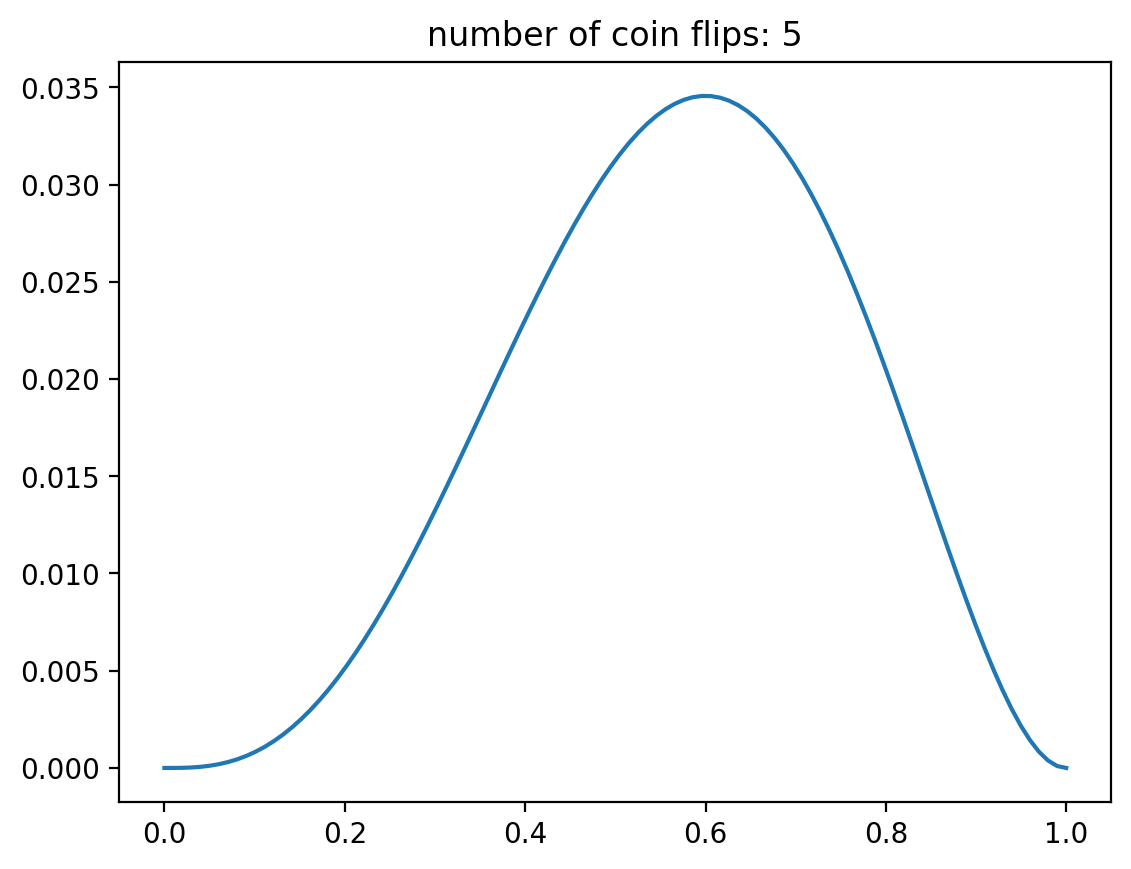

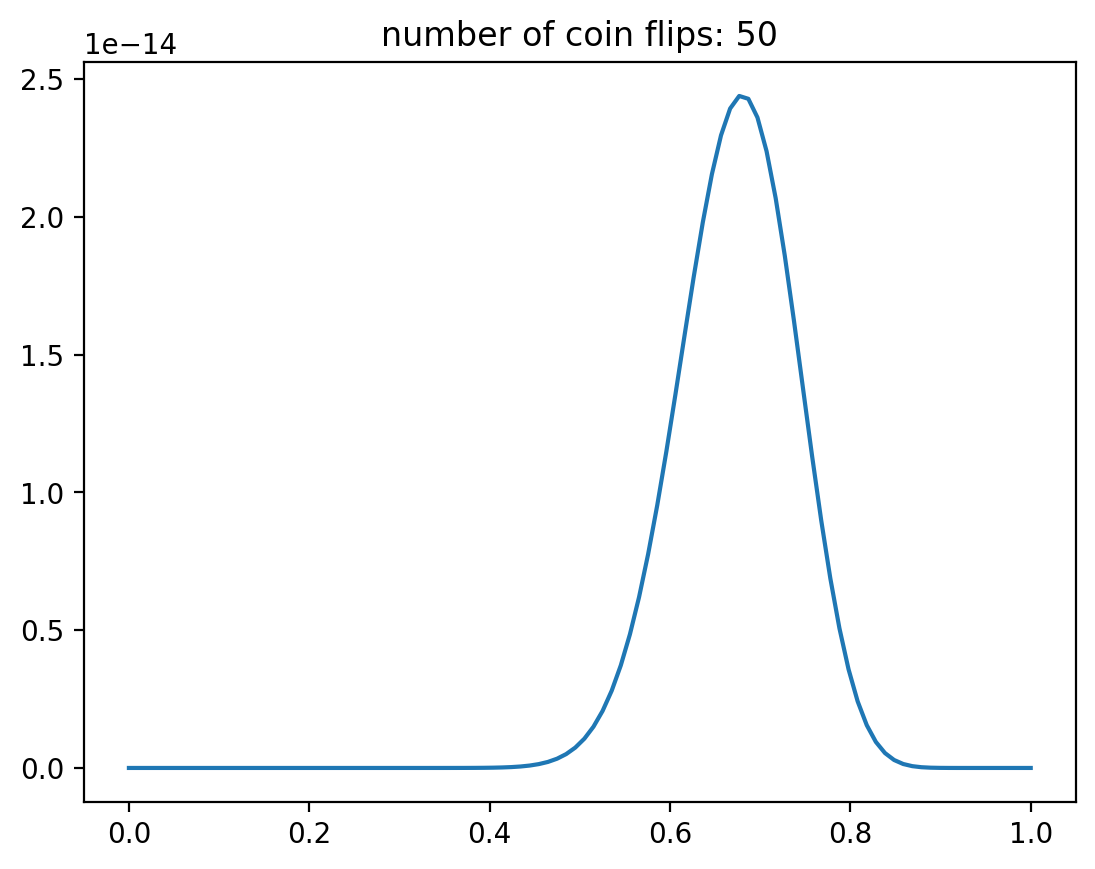

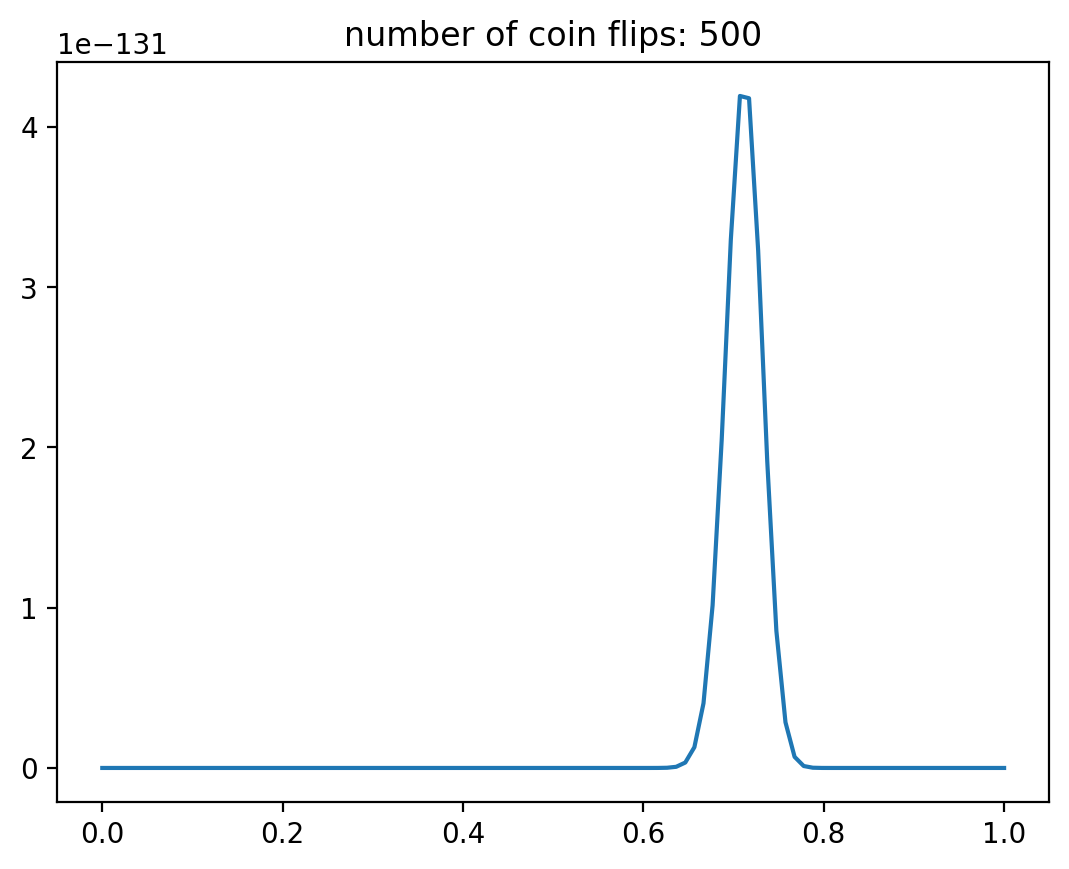

In [8]:
def p_nheads(n, h, theta):
    return (theta**h) * ((1-theta)**(n-h))

# likelihood
def L(data, ntrials, theta):
    nheads = data[:ntrials].sum()
    return p_nheads(ntrials, nheads, theta)

# prior. Just uniform?
def prior(theta):
    return 1

probs = []
# define the number of trials
n_trials = [5, 50, 500]
theta = np.linspace(0, 1, 100)
for nt in n_trials:
    prob = L(data, nt, theta) * prior(theta)
    # posterior plot
    plt.plot(theta, prob, 
            label=r'ntrial = '+str(nt))
    # likelihood plot
    #plt.plot(theta, L(data, nt, theta))
    plt.title("number of coin flips: "+str(nt))  
    plt.show()

Careful that we're not tracking the normalization! But that's ok. We can trivially normalize the curve if we need it (most times we don't...)

Say you know this gambler already. What if I used a $\beta$ function for the prior?

$P(\alpha, \beta, \theta) = \theta^{\alpha-1} (1-\theta)^{(\beta-1)}$

![](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f3/Beta_distribution_pdf.svg/1200px-Beta_distribution_pdf.svg.png)


Let's use a $\beta$ function prior on $\theta$ with $a=1$ and $b=10$. You can code this directly or grab from `scipy.stats`.

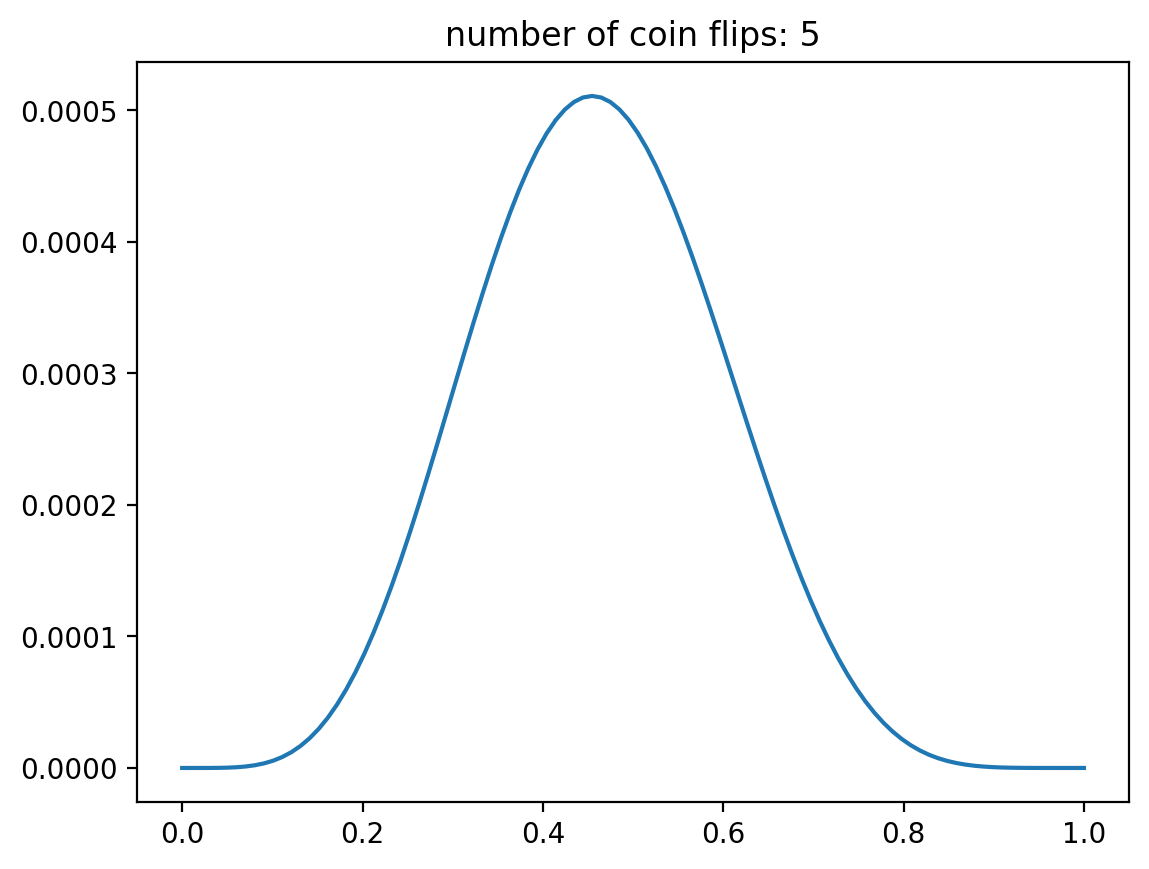

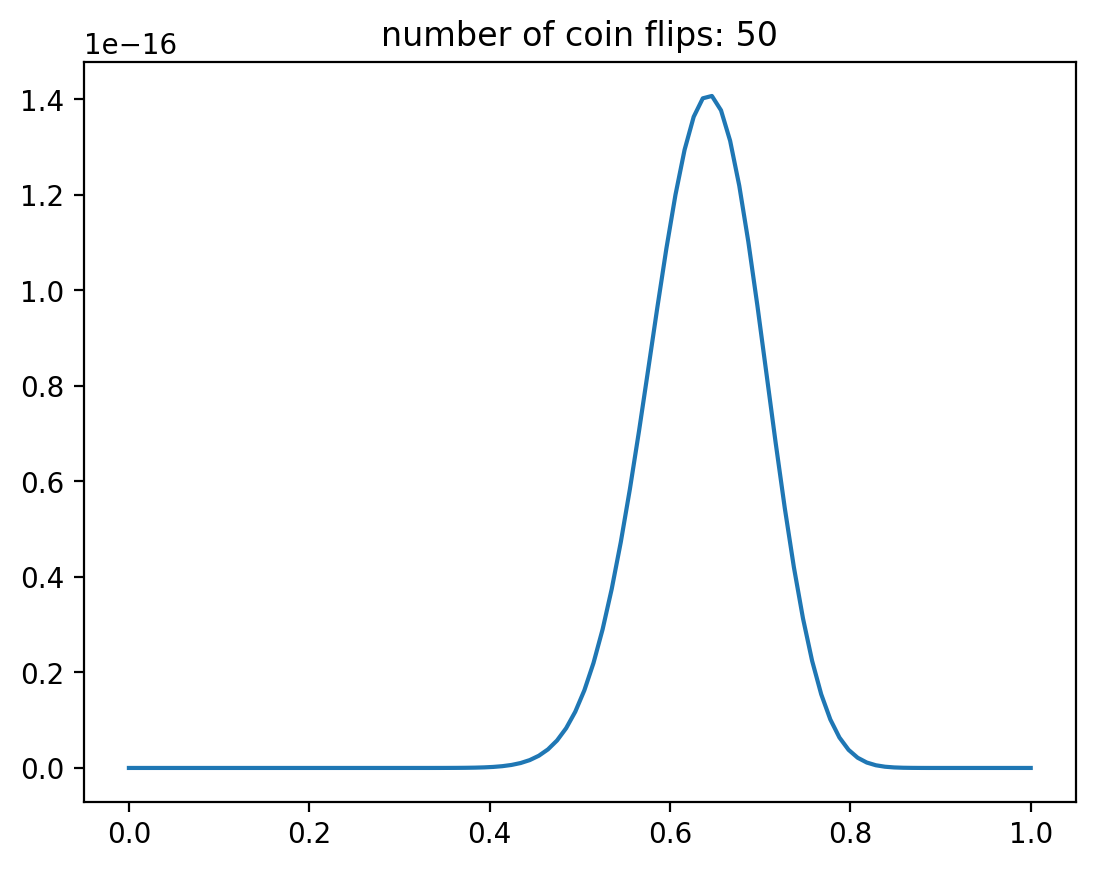

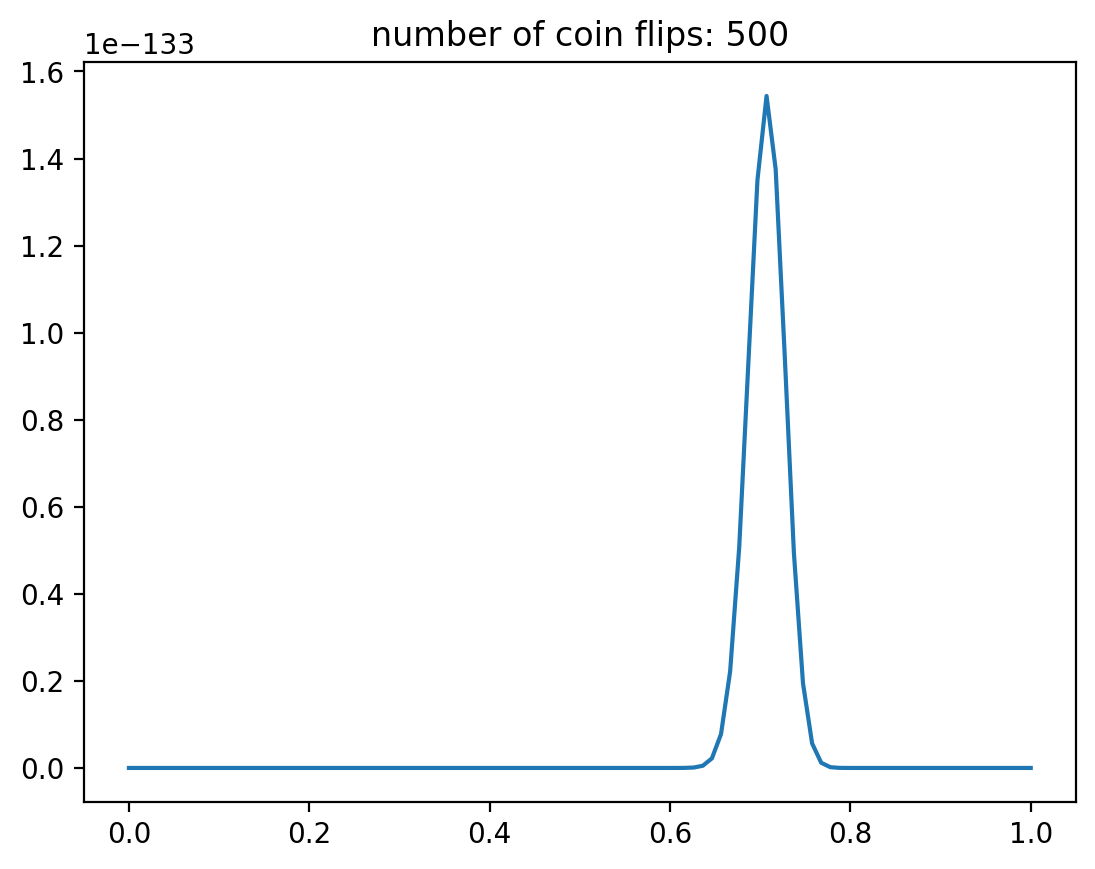

In [9]:
def p_nheads(n, h, theta):
    return (theta**h) * ((1-theta)**(n-h))

# likelihood
def L(data, ntrials, theta):
    nheads = data[:ntrials].sum()
    return p_nheads(ntrials, nheads, theta)

def prior(theta):
    alpha=2
    beta=5
    return  (theta**alpha) * ((1-theta)**(beta-1))

probs = []
# define the number of trials
n_trials = [5, 50, 500]
theta = np.linspace(0, 1, 100)
for nt in n_trials:
    prob = L(data, nt, theta) * prior(theta)
    # posterior plot
    plt.plot(theta, prob, 
            label=r'ntrial = '+str(nt))
    # likelihood plot
    #plt.plot(theta, L(data, nt, theta))
    plt.title("number of coin flips: "+str(nt))  
    plt.show()

The first case is different, the last one is not. As the amount of data increases, inference becomes data driven and the chosen prior is less important. Often we don't have this luxury!

### Nuisance parameters and marginalization

#### Heteroscedastic Gaussian as an example


Consider the case of measuring a star when you know your telescope very well.  We want to know the posterior pdf for the brigthness of the star, $p(\theta|D) \equiv p(\mu|\{x_i\},\{\sigma_i\})$ (so I'm not trying to estimate the sigmas from the data, I know them already).

For the likelihood we have (same as before!)

$$L = p(\{x_i\}|\mu) = \prod_{i=1}^N \frac{1}{\sigma_i\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}
{2\sigma_i^2}\right).$$

---

**In the Bayesian case, we also need a prior.**  We'll adopt a *flat uniform distribution* given by

$$p(\mu) = C, \; {\rm for} \; \mu_{\rm min} < \mu < \mu_{\rm max},$$

where $C = \frac{1}{\mu_{\rm max} - \mu_{\rm min}}$ between the min and max and is $0$ otherwise.

The log of the posterior pdf is then

$$\ln p = {\rm constant} - \sum_{i=1}^N \frac{(x_i - \mu)^2}{2\sigma_i^2}.$$

This is exactly the same as we saw before, except that the value of the constant is different.  Since the constant doesn't come into play, we get the same result as before. The MAP is:
 
$$\mu^0 = \frac{\sum_i^N (x_i/\sigma_i^2)}{\sum_i^N (1/\sigma_i^2)},$$

with uncertainty

$$\sigma_{\mu} = \left( \sum_{i=1}^N \frac{1}{\sigma_i^2}\right)^{-1/2}.$$
 
We get the same result because we used a flat prior. If the case were homoscedastic instead of heteroscedastic, we obviously would get the result from our first example.

---

Now let's consider the case where **$\sigma$ is not known**, but rather it needs to be determined from the data, too. This might be because I cannot trust my assumption on how the sky will behave tonight. 

I want to use the data to measure **both** the star and the properties of the sky. But crucially, I only care about the star.

In this case, the posterior pdf that we seek is not $p(\mu|\{x_i\},\{\sigma_i\})$, but rather the joint $2$D pdf $p(\mu,\sigma|\{x_i\})$.

As before we have

$$L = p(\{x_i\}|\mu,\sigma) = \prod_{i=1}^N \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma^2}\right),$$

except that now $\sigma$ is uknown.

---

Our Bayesian prior is *now 2D instead of 1D* and we'll adopt (invariance, see above)

$$p(\mu,\sigma) \propto \frac{1}{\sigma},\; {\rm for} \; \mu_{\rm min} < \mu < \mu_{\rm max} \; {\rm and} \; \sigma_{\rm min} < \sigma < \sigma_{\rm max}.$$

With proper normalization, we have

$$p(\{x_i\}|\mu,\sigma)p(\mu,\sigma) = C\frac{1}{\sigma^{(N+1)}}\prod_{i=1}^N \exp\left( \frac{-(x_i-\mu)^2}{2\sigma^2}  \right),$$

where

$$C = (2\pi)^{-N/2}(\mu_{\rm max}-\mu_{\rm min})^{-1} \left[\ln \left( \frac{\sigma_{\rm max}}{\sigma_{\rm min}}\right) \right]^{-1}.$$

The log of the posterior pdf is

$$\ln[p(\mu,\sigma|\{x_i\})] = {\rm constant} - (N+1)\ln\sigma - \sum_{i=1}^N \frac{(x_i - \mu)^2}{2\sigma^2}.$$

Since we are assuming a Gaussian distribution, the mean, $\overline{x}$, and the variance, $V (=s^2)$, completely characterize the distribution. So we can write this expression in terms of those variables instead of $x_i$.  Skipping over the math details (see textbook $\S$5.6.1), we find

$$\ln[p(\mu,\sigma|\{x_i\})] = {\rm constant} - (N+1)\ln\sigma - \frac{N}{2\sigma^2}\left( (\overline{x}-\mu)^2 + V  \right).$$

Note that this expression only contains the 2 parameters that we are trying to determine: $(\mu,\sigma)$ and 3 values that we can determine directly from the data: $(N,\overline{x},V)$. A side note: these three data-based values fully encapsulate our dataset and are called *sufficient statistics*.

This code visualizes the posterior pdf for the case of $(N,\overline{x},V)=(10,1,4)$. Play around with it  changing the values of $(N,\overline{x},V)$.</font> 

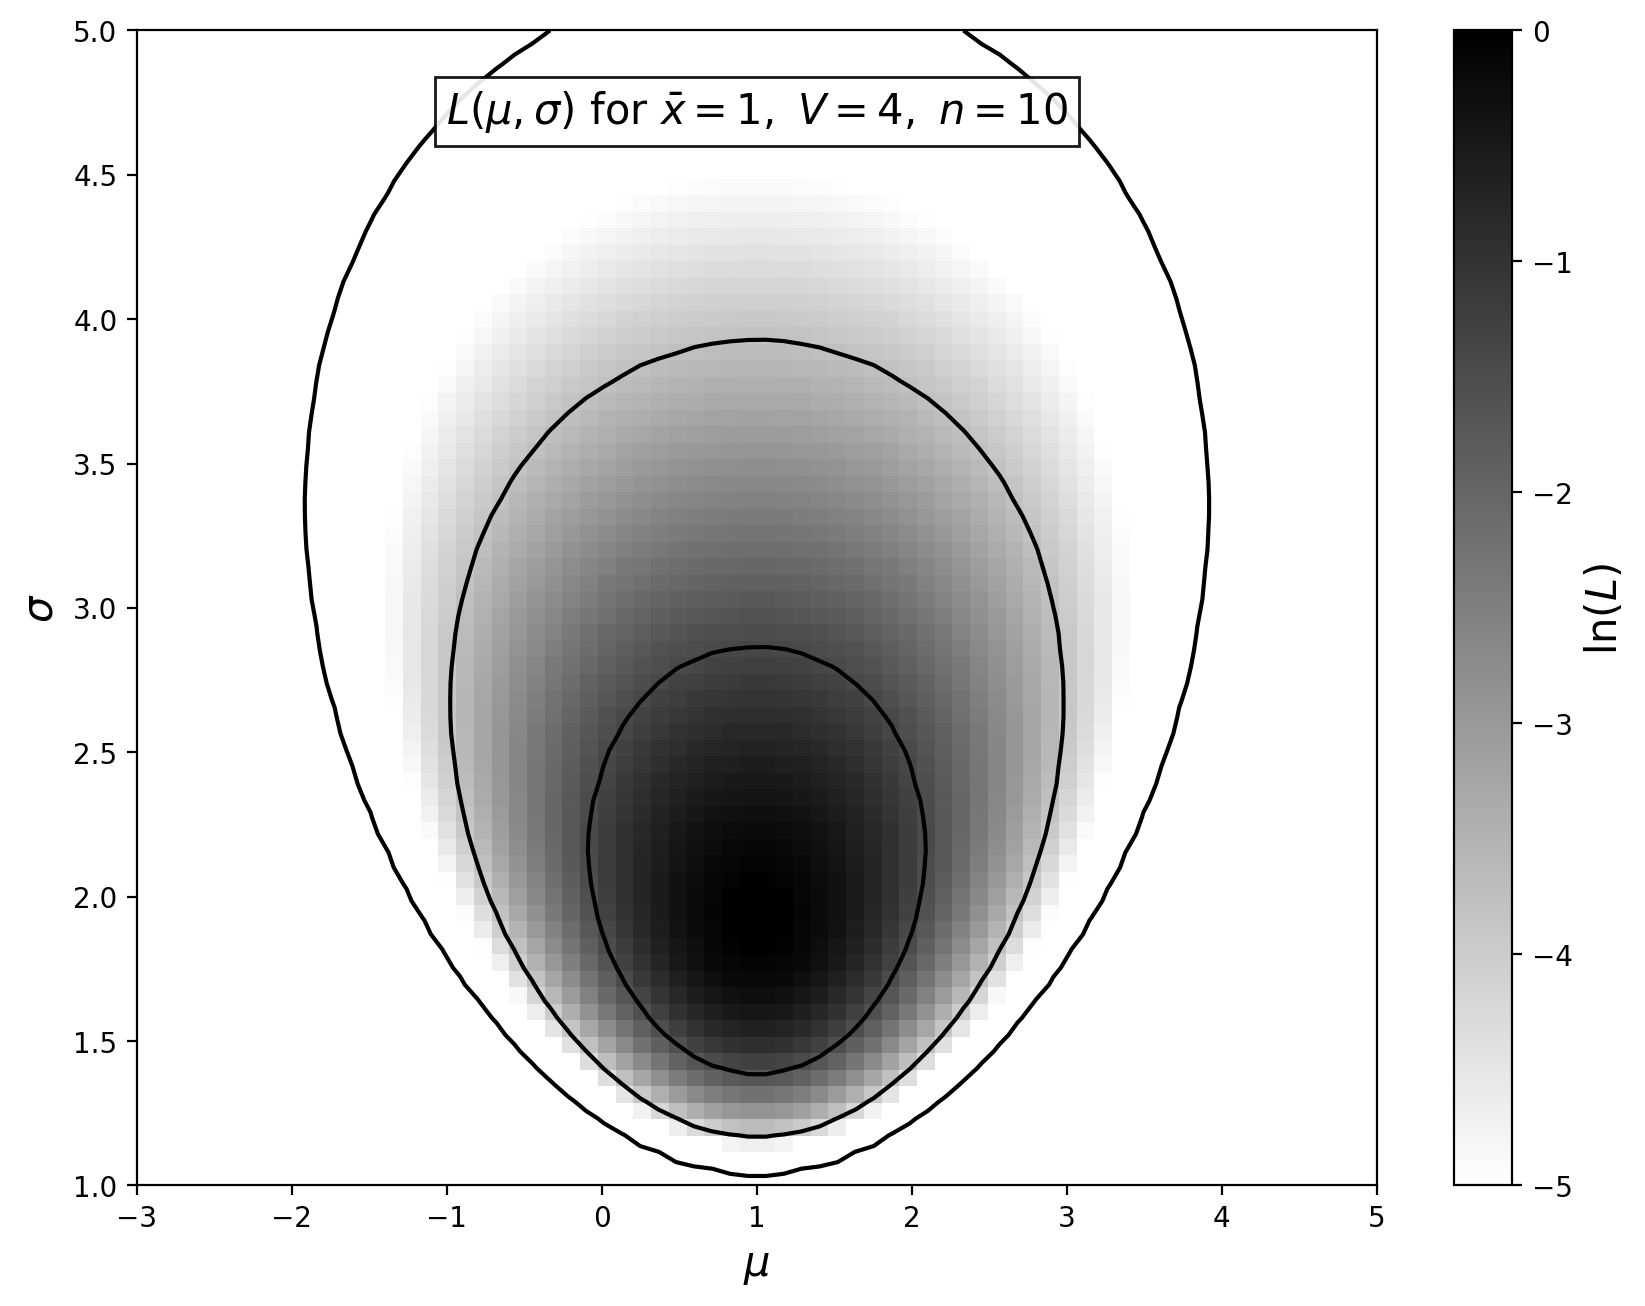

In [7]:
# %load code/fig_likelihood_gaussian.py
"""
Log-likelihood for Gaussian Distribution
----------------------------------------
Figure5.4
An illustration of the logarithm of the posterior probability density
function for :math:`\mu` and :math:`\sigma`, :math:`L_p(\mu,\sigma)`
(see eq. 5.58) for data drawn from a Gaussian distribution and N = 10, x = 1,
and V = 4. The maximum of :math:`L_p` is renormalized to 0, and color coded as
shown in the legend. The maximum value of :math:`L_p` is at :math:`\mu_0 = 1.0`
and :math:`\sigma_0 = 1.8`. The contours enclose the regions that contain
0.683, 0.955, and 0.997 of the cumulative (integrated) posterior probability.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from astroML.plotting.mcmc import convert_to_stdev

def gauss_logL(xbar, V, n, sigma, mu):
    """Equation 5.57: gaussian likelihood"""
    return (-(n + 1) * np.log(sigma)
            - 0.5 * n * ((xbar - mu) ** 2 + V) / sigma ** 2)

#------------------------------------------------------------
# Define the grid and compute logL
sigma = np.linspace(1, 5, 70)
mu = np.linspace(-3, 5, 70)
xbar = 1
V = 4
n = 10

logL = gauss_logL(xbar, V, n, sigma[:, np.newaxis], mu)
logL -= logL.max()

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 7.5))
plt.imshow(logL, origin='lower',
           extent=(mu[0], mu[-1], sigma[0], sigma[-1]),
           cmap=plt.cm.binary,
           aspect='auto')
plt.colorbar().set_label(r'$\ln(L)$', fontsize=15)
plt.clim(-5, 0)

plt.contour(mu, sigma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='k')

plt.text(0.5, 0.93, r'$L(\mu,\sigma)\ \mathrm{for}\ \bar{x}=1,\ V=4,\ n=10$',
         bbox=dict(ec='k', fc='w', alpha=0.9),
         ha='center', va='center', 
         fontsize=15, transform=plt.gca().transAxes)

plt.xlabel(r'$\mu$', fontsize=15)
plt.ylabel(r'$\sigma$', fontsize=15)

plt.show()

**What if we don't care that much about $\sigma$?** e.g. it may simply represent how good our measuring apparatus is - what we might get a Nobel prize for is $\mu$ (the brightest star in the Universe!).
- Therefore, what we want is $p(\mu|\{x_i\})$, rather than $p(\mu,\sigma|\{x_i\})$. 
- We can get the former from the latter by the **marginalization over $\sigma$**, which means integration of $p(\mu,\sigma|\{x_i\})$ over $\sigma$: 

$$ p(\mu\,|\,\{x_i\}) = \int_0^\infty p(\mu,\sigma|\{x_i\}) d\sigma$$
and thus (using the substitution $t$ = 1/$\sigma$ and integration by parts)

$$ p(\mu\,|\,\{x_i\}) \propto \left(1 + \frac{(\overline{x}-\mu)^2}{V} \right)^{-N/2}. $$

It is easy to show that this result corresponds to *Student’s $t$ distribution* (this is a nice proof, Google it!) with 
$k = N-1$ degrees of freedom for the variable $t = (x-\mu)/(s/\sqrt{N})$, where $s$ is the sample 
standard deviation. The Student’s $t$ distribution is symmetric and bell shaped, but with heavier 
tails than  a Gaussian distribution.  

**Hold on!** This is not a Gaussian distribution promised by the Central Limit Theorem! That's fine, the CLT promised a Gaussian only for large $N$. Indeed, the above expression (Student's $t$ distribution) morphs into a Gaussian for large $N$.

This is the marginalized posterior on $\mu$:

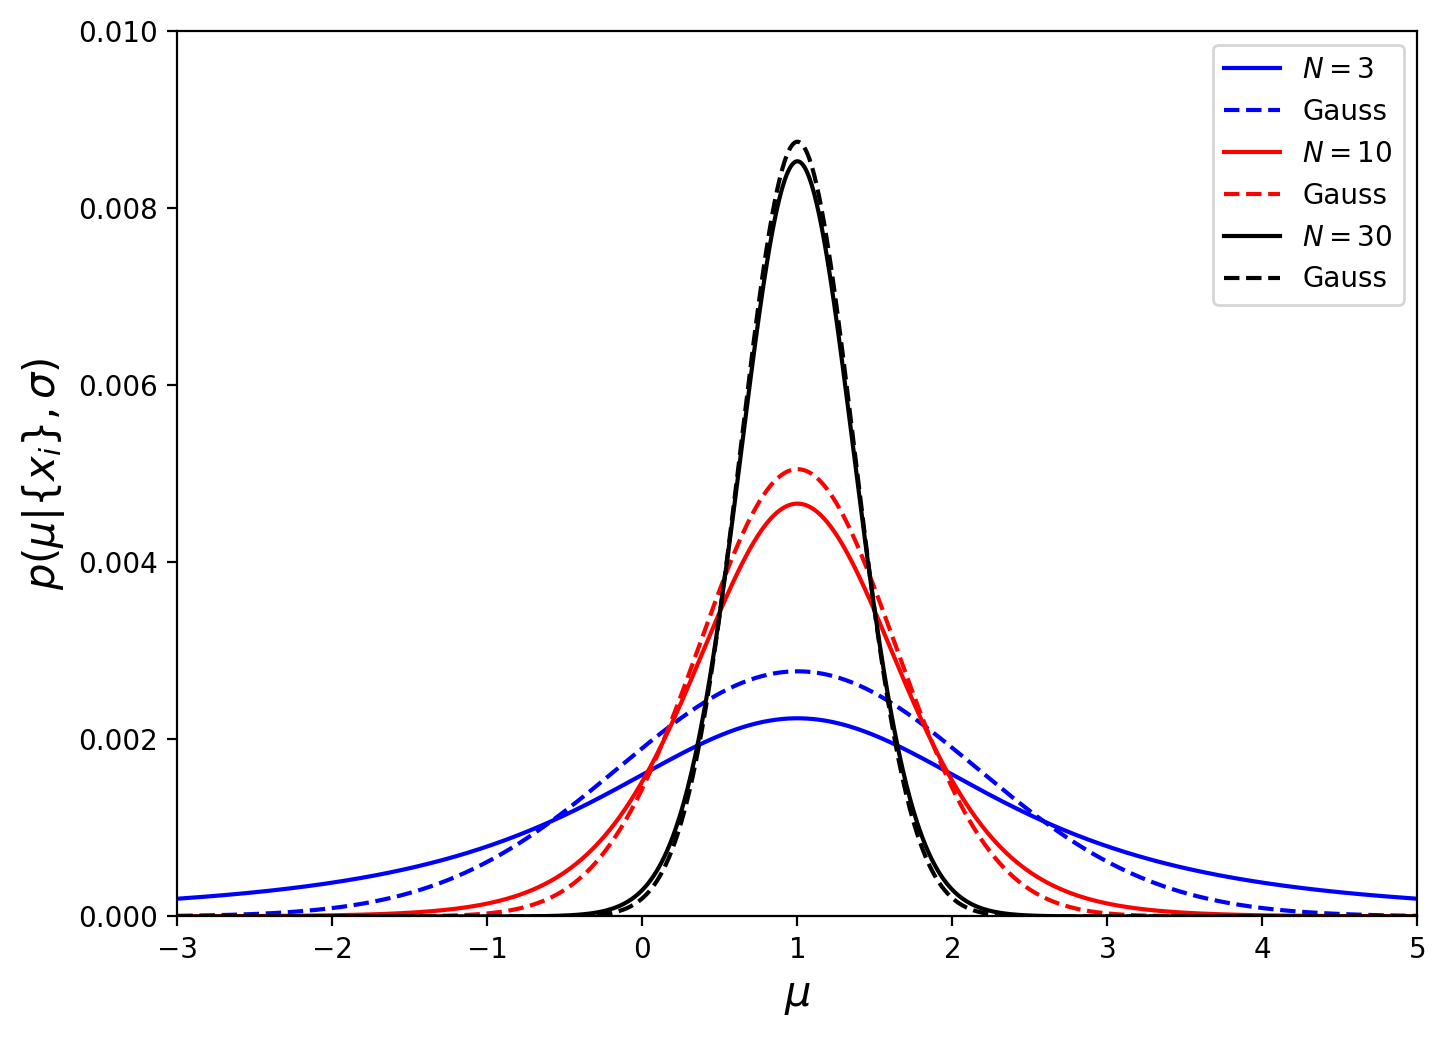

In [8]:
### let's see how Student's t distribution morphs into Gaussian distribution
# let's first choose mean x and variance as in the previous example
mu = np.linspace(-3, 5, 1000)
xbar = 1.0
V = 4.0

# and now let's generate p(mu) for N=3, 10 and 20
def compute_pmu(mu, xbar, V, N):
    p = (1 + (xbar - mu) ** 2 / V) ** (-0.5 * N)
    return p / np.sum(p)
#
N1 = 3
pmu1 = compute_pmu(mu,xbar,V,N1)
G1 = norm(xbar, np.sqrt(V/N1)).pdf(mu) 
G1norm = G1 / np.sum(G1)

N2 = 10
pmu2 = compute_pmu(mu,xbar,V,N2)
G2 = norm(xbar, np.sqrt(V/N2)).pdf(mu) 
G2norm = G2 / np.sum(G2)

N3 = 30
pmu3 = compute_pmu(mu,xbar,V,N3)
G3 = norm(xbar, np.sqrt(V/N3)).pdf(mu) 
G3norm = G3 / np.sum(G3)
 
## plot
fig, ax = plt.subplots(figsize=(8, 5.75))
plt.plot(mu, pmu1, ls='-', c='blue', label=r'$N=3$')
plt.plot(mu, G1norm, ls='--', c='blue', label=r'Gauss')
plt.plot(mu, pmu2, ls='-', c='red', label=r'$N=10$')
plt.plot(mu, G2norm, ls='--', c='red', label=r'Gauss')
plt.plot(mu, pmu3, ls='-', c='black', label=r'$N=30$')
plt.plot(mu, G3norm, ls='--', c='black', label=r'Gauss')

plt.xlim(-3, 5)
plt.ylim(0, 0.01)
plt.xlabel('$\mu$', fontsize=15)
plt.ylabel(r'$p(\mu | \{x_i\},\sigma)$', fontsize=15)
plt.legend()
plt.show() 

- The main result here is that **for smallish N ($<$10 or so), $p(\mu)$ is not Gaussian**. 

<div class="alert alert-block alert-danger">
So using Gaussians all the time is not fine! Even such a simple case like this where I'm measuing $\mu$ and $\sigma$ from Gaussian measurements. Remember: you can consistently do least squares fits only for Gaussian data! Here is not ok. Welcome to the real world.
</div>

- The code above can be used to compute $p(\mu)$ for arbitrary values of N, $\overline{x}$ and V.
- For large N, Gaussian is a good approximation of $p(\mu)$. 

The top panels of the figure below (textbook figure 5.5, for the code see the 
[astroML website](http://www.astroml.org/book_figures/chapter5/fig_posterior_gaussian.html)) show marginal distributions $p(\mu)$ and $p(\sigma)$ for $(N,\overline{x},V)=(10,1,4)$.

- Blue solid line is the analytic Bayesian result with uninformative prior, i.e. $p(\sigma)\propto 1/\sigma$
- Red dotted line is the result for a uniform prior (note that there is not that much difference).
- Red dashed line is the analytic MLE result, which is quite different!
- Circles indicate the distributions of bootstrap estimates.

The bottom panels show the cumulative distributions.

![Ivezic, Figure 5.5](http://www.astroml.org/_images/fig_posterior_gaussian_1.png)
 